# Import Modules & Config

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error
from sklearn import tree
from sklearn.ensemble._forest import _generate_sample_indices
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf
from hijridate import Hijri

sugar_selector = widgets.Dropdown(
    options=['local', 'premium'],
    value='local',
    description='Sugar Type',
)

train_size_slider = widgets.FloatSlider(
    value=0.8,
    min=0.6,
    max=0.9,
    step=0.05,
    description='Train Size'
)

use_validation_checkbox = widgets.Checkbox(
    value=True,
    description='Use Validation Split'
)

validation_size_slider = widgets.FloatSlider(
    value=0.1,
    min=0.05,
    max=0.3,
    step=0.05,
    description='Validation Size',
    layout=widgets.Layout(display='')
)

# Show/hide validation slider based on checkbox
def _toggle_validation(change):
    if change['new']:
        validation_size_slider.layout.display = ''
    else:
        validation_size_slider.layout.display = 'none'

use_validation_checkbox.observe(_toggle_validation, names='value')

history_plot_checkbox = widgets.Checkbox(
  value=False,
  description='Generate History Plot'
)

pacf_plot_checkbox = widgets.Checkbox(
  value=False,
  description='Generate PACF Plot'
)

compare_prediction_checkbox = widgets.Checkbox(
  value=False,
  description='Generate Actual vs Prediction Plot'
)

forecast_checkbox = widgets.Checkbox(
  value=False,
  description='Forecast Sugar Prices'
)

gridsearch_checkbox = widgets.Checkbox(
  value=False,
  description='Hyperparameters Tuning'
)


benchmark_split_checkbox = widgets.Checkbox(
  value=False,
  description='Benchmark Split Ratios'
)

# Hide single-split widgets when benchmark is enabled
def _toggle_benchmark(change):
    if change['new']:
        train_size_slider.layout.display = 'none'
        use_validation_checkbox.layout.display = 'none'
        validation_size_slider.layout.display = 'none'
    else:
        train_size_slider.layout.display = ''
        use_validation_checkbox.layout.display = ''
        if use_validation_checkbox.value:
            validation_size_slider.layout.display = ''

benchmark_split_checkbox.observe(_toggle_benchmark, names='value')

missing_data_selector = widgets.Dropdown(
    options=['drop', 'interpolate', 'ffill_bfill'],
    value='ffill_bfill',
    description='Missing Data Method',
    style={'description_width': 'initial'}
)

inspect_per_file_checkbox = widgets.Checkbox(
  value=False,
  description='Inspect & Evaluate per File'
)

# ── Optional RFR Features ─────────────────────────────────────────────────
use_optional_features_checkbox = widgets.Checkbox(
    value=False,
    description='Use Optional Features',
)

# Container for all optional-feature checkboxes (hidden when master toggle is off)
_optional_features_box_layout = widgets.Layout(
    display='none',
    flex_flow='column',
    border='1px solid #ccc',
    padding='6px 10px',
    margin='4px 0 8px 20px',
)

# ── Optional Feature: Eid Window (14-day window) ───────────────────────────
# 7 days before Eid al-Fitr, the day itself, and 6 days after.
eid_window_checkbox = widgets.Checkbox(
    value=True,
    description='Eid Window Feature (14-day)',
)

_optional_features_box = widgets.VBox(
    children=[eid_window_checkbox],
    layout=_optional_features_box_layout,
)

def _toggle_optional_features(change):
    _optional_features_box.layout.display = '' if change['new'] else 'none'

use_optional_features_checkbox.observe(_toggle_optional_features, names='value')

display(sugar_selector)
display(inspect_per_file_checkbox)
display(missing_data_selector)
display(train_size_slider)
display(use_validation_checkbox)
display(validation_size_slider)
display(history_plot_checkbox)
display(pacf_plot_checkbox)
display(compare_prediction_checkbox)
display(forecast_checkbox)
display(gridsearch_checkbox)
display(benchmark_split_checkbox)
display(use_optional_features_checkbox)
display(_optional_features_box)

Dropdown(description='Sugar Type', options=('local', 'premium'), value='local')

Checkbox(value=False, description='Inspect & Evaluate per File')

Dropdown(description='Missing Data Method', index=2, options=('drop', 'interpolate', 'ffill_bfill'), style=Des…

FloatSlider(value=0.8, description='Train Size', max=0.9, min=0.6, step=0.05)

Checkbox(value=True, description='Use Validation Split')

...

Checkbox(value=False, description='Generate Actual vs Prediction Plot')

Checkbox(value=False, description='Forecast Sugar Prices')

Checkbox(value=False, description='Hyperparameters Tuning')

Checkbox(value=False, description='Benchmark Split Ratios')

Checkbox(value=False, description='Use Optional Features')

In [43]:
sugar_type = sugar_selector.value
train_size = train_size_slider.value
use_validation = use_validation_checkbox.value
validation_size = validation_size_slider.value if use_validation else 0.0
generate_history_plot = history_plot_checkbox.value
generate_pacf_plot = pacf_plot_checkbox.value
compare_prediction = compare_prediction_checkbox.value
forecast_price = forecast_checkbox.value
exec_gridsearch = gridsearch_checkbox.value
run_benchmark = benchmark_split_checkbox.value
missing_data_method = missing_data_selector.value
inspect_per_file = inspect_per_file_checkbox.value
use_optional_features = use_optional_features_checkbox.value
use_eid_window = use_optional_features and eid_window_checkbox.value


# Data Selection

In [44]:
raw_datasets: dict[str, pd.DataFrame] = {}

# Specify where datasets stored
raw_dataset_dir = Path(f"../dataset/{sugar_type}/raw")
paths = sorted(raw_dataset_dir.glob("*.xlsx"))

# Check if datasets exists
if not paths:
    raise FileNotFoundError(
        f"Tidak ditemukan dataset .xlsx pada {raw_dataset_dir.resolve()}"
    )

# Print loaded dataset
print(f"Loaded Dataset ({sugar_type} price) :")
for path in paths:
    name = path.stem
    print(f"{path.name}")
    # Read dataset, Drop unnecessary column, and Revise columns name
    df_raw = (
        pd.read_excel(path)
        .drop(columns=["No"])
        .rename(columns={"Komoditas (Rp)": "Province"})
    )
    # Drop summary row
    df_raw = df_raw[~df_raw["Province"].isin(["Semua Provinsi", "Maluku Utara"])].reset_index(drop=True)
    raw_datasets[name] = df_raw.reset_index(drop=True)

Loaded Dataset (local price) :
2022.xlsx
2023.xlsx
2024.xlsx
2025.xlsx
2026.xlsx


## Data Inspection
Check each raw dataset for missing information before cleaning.

In [45]:
missing_info = []

for name, df in raw_datasets.items():
    date_cols = [c for c in df.columns if c not in ["Province"]]
    
    # 1. Count Missing Values in existing columns
    missing_mask = df[date_cols].apply(
        lambda col: col.astype(str).str.strip().isin(["-", "", "nan", "NaN"]) | col.isna()
    )
    missing_vals = missing_mask.sum().sum()
    
    # Parse dates and get valid sorted dates
    parsed_dates = pd.to_datetime(
        pd.Series(date_cols).str.replace(" ", "").str.strip(),
        format="%d/%m/%Y",
        errors="coerce"
    )
    
    valid_dates = parsed_dates.dropna()
    sorted_valid_dates = valid_dates.sort_values()
    
    if not sorted_valid_dates.empty:
        min_date = sorted_valid_dates.min()
        max_date = sorted_valid_dates.max()
        expected_days = (max_date - min_date).days + 1
        missing_dates = expected_days - len(sorted_valid_dates)
        
        # Calculate max consecutive missing dates
        date_diffs = sorted_valid_dates.diff().dt.days
        max_consecutive_missing_dates = int((date_diffs.max() - 1)) if pd.notna(date_diffs.max()) and date_diffs.max() > 1 else 0
    else:
        missing_dates = 0
        max_consecutive_missing_dates = 0
        
    # Calculate max consecutive missing values per province
    # First, sort the columns by date so we check consecutively in time
    date_df = pd.DataFrame({"col_name": date_cols, "date": parsed_dates})
    sorted_date_cols = date_df.dropna(subset=["date"]).sort_values("date")["col_name"].tolist()
    
    max_consecutive_missing_vals = 0
    if sorted_date_cols:
        import itertools
        sorted_missing_mask = missing_mask[sorted_date_cols]
        for _, row in sorted_missing_mask.iterrows():
            is_missing = row.values
            max_row = max((sum(1 for _ in g) for k, g in itertools.groupby(is_missing) if k), default=0)
            if max_row > max_consecutive_missing_vals:
                max_consecutive_missing_vals = max_row
                
    missing_info.append({
        "Dataset": name,
        "Missing Dates (Total)": missing_dates,
        "Max Consecutive Missing Dates": max_consecutive_missing_dates,
        "Missing Values (Total Cells)": missing_vals,
        "Max Consecutive Missing Values": max_consecutive_missing_vals
    })

df_missing = pd.DataFrame(missing_info)
print("=== Missing Data Information ===")
display(df_missing)

=== Missing Data Information ===


,Dataset,Missing Dates (Total),Max Consecutive Missing Dates,Missing Values (Total Cells),Max Consecutive Missing Values
0,2022,102,2,451,6
1,2023,102,2,160,5
2,2024,104,2,70,2
3,2025,104,2,16,3
4,2026,26,2,1,1


# Data Cleaning

In [46]:
# Specify where cleaned dataset stored
clean_dataset_dir = Path(f"../dataset/{sugar_type}/clean")
clean_dataset_dir.mkdir(parents=True, exist_ok=True)

cleaned_datasets: dict[str, pd.DataFrame] = {}

# Loop process to clean each raw dataset
for name, df in raw_datasets.items():
    # Select Date
    date_cols = [c for c in df.columns if c not in ["Province"]]

    # Change dataset format from wide to long
    df_long = df.melt(
        id_vars=["Province"],
        value_vars=date_cols,
        var_name="Date",
        value_name="Price",
    )

    # Clean date column by removing space and change date format
    df_long["Date"] = pd.to_datetime(
        df_long["Date"].str.replace(" ", "").str.strip(),
        format="%d/%m/%Y",
        errors="coerce",
    )

    # Clean price column by replacing "-" with NaN, remove comma, and format to numeric
    df_long["Price"] = (
        df_long["Price"]
        .astype(str)
        .str.strip()
        .replace("-", np.nan)
        .str.replace(",", "", regex=False)
    )
    df_long["Price"] = pd.to_numeric(df_long["Price"], errors="coerce")

    # Handling Missing Data (Values and Dates)
    if missing_data_method == "drop":
        # Drop rows with missing prices (implicitly drops missing dates as well)
        df_long = df_long.dropna(subset=["Price"])
    elif missing_data_method == "interpolate":
        # Interpolate based on each Province
        df_long = (
            df_long.groupby("Province", sort=False, group_keys=False)[["Date", "Price", "Province"]]
            .apply(
                lambda g: (
                    g.set_index("Date")
                    .reindex(
                        pd.date_range(
                            start=g["Date"].min(),
                            end=g["Date"].max(),
                            freq="D",
                        )
                    )
                    .assign(Province=lambda x: x["Province"].ffill().bfill())
                    .assign(
                        Price=lambda x: x["Price"].interpolate(method='time').ffill().bfill()
                    )
                    .rename_axis("Date")
                    .reset_index()
                )
            )
            .reset_index(drop=True)
        )
    else: # ffill_bfill
        # Forward/Backward Fill Based Each Province
        df_long = (
            df_long.groupby("Province", sort=False, group_keys=False)[["Date", "Price", "Province"]]
            .apply(
                lambda g: (
                    g.set_index("Date")
                    .reindex(
                        pd.date_range(
                            start=g["Date"].min(),
                            end=g["Date"].max(),
                            freq="D",
                        )
                    )
                    .assign(Province=lambda x: x["Province"].ffill().bfill())
                    .assign(
                        Price=lambda x: x["Price"].ffill().bfill()
                    )
                    .rename_axis("Date")
                    .reset_index()
                )
            )
            .reset_index(drop=True)
        )
    
    # Sort by date and province
    df_long = df_long.sort_values(["Date", "Province"]).reset_index(drop=True)

    # Round price
    df_long["Price"] = df_long["Price"].round().astype(int)

    # Export cleaned dataframe
    file_name = f"Clean_{name}.xlsx"
    df_long.to_excel(clean_dataset_dir / file_name, index=False)

    # Save to dictionary
    cleaned_datasets[name] = df_long


# Data Integration

In [47]:
merged_dataset_path = Path(f"../dataset/{sugar_type}/merged/merged_datasets.xlsx")
merged_dataset_path.parent.mkdir(parents=True, exist_ok=True)

frames: list[pd.DataFrame] = []

for name, df_transform in cleaned_datasets.items():
    new_df = df_transform.copy()
    frames.append(new_df)

# Merge all dataset
df_merged = pd.concat(frames, ignore_index=True)

# Sort and drop duplicate each province and date
# If there's duplicate data, get the last one
df_merged = df_merged.drop_duplicates(
    subset=["Province", "Date"], keep="last"
).reset_index(drop=True)

# Export merged dataframe
df_merged.to_excel(merged_dataset_path)

# Data Transformation

In [48]:
# Specify where transformed dataset stored
transformed_dataset_path = Path(f"../dataset/{sugar_type}/transformed/transformed_datasets.xlsx")
transformed_dataset_path.parent.mkdir(parents=True, exist_ok=True)

df = df_merged.copy()

# Data type normalization
df["Date"] = pd.to_datetime(df["Date"])
df["Province"] = df["Province"].astype("string")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Feature Engineering
## 1) Province → numeric (ID)
# Calculate average price for each province
province_mean_prices = df.groupby("Province")["Price"].mean().sort_values()
# Create a mapping dictionary from province name to a rank (0 to 33)
province_mapping = {province: i for i, province in enumerate(province_mean_prices.index)}
df["Province_id"] = df["Province"].map(province_mapping)

## 2) Lag features for each province
for lag in [1]:
    df[f"lag_{lag}"] = df.groupby("Province", group_keys=False)["Price"].shift(lag)

## 3) Time based features
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year

## 4) Optional features
if use_optional_features:
    # ── Eid al-Fitr Window features ────────────────────────────────────────
    # Derives Eid al-Fitr (1 Syawal) dates dynamically from the Hijri calendar
    # for every year present in the data, then labels each Gregorian date as:
    #   before_eid : 1 if the date falls within 7 days before Eid, else 0
    #   eid        : 1 if the date is Eid day itself (1 Syawal), else 0
    #   after_eid  : 1 if the date falls within 6 days after Eid, else 0
    if use_eid_window:
        # Derive Eid dates for all years covered by the dataset
        years_in_data = df["Date"].dt.year.unique()
        eid_gregorian_dates = []
        for greg_year in years_in_data:
            # Convert 1 Jan of that Gregorian year to Hijri to get the
            # approximate Hijri year, then check both h_year and h_year+1
            # to handle years where Eid falls in the next Hijri year.
            from hijridate import Gregorian as HGregorian
            h_year = HGregorian(greg_year, 1, 1).to_hijri().year
            for hy in [h_year, h_year + 1]:
                try:
                    eid_date = Hijri(hy, 10, 1).to_gregorian()
                    eid_ts = pd.Timestamp(str(eid_date))
                    if eid_ts.year == greg_year:
                        eid_gregorian_dates.append(eid_ts)
                except Exception:
                    pass
        eid_gregorian_dates = list(set(eid_gregorian_dates))

        def _eid_label(date):
            for eid in eid_gregorian_dates:
                delta = (date - eid).days
                if delta == 0:
                    return "eid"
                if -7 <= delta <= -1:
                    return "before_eid"
                if 1 <= delta <= 6:
                    return "after_eid"
            return None

        _eid_series = df["Date"].apply(_eid_label)
        df["before_eid"] = (_eid_series == "before_eid").astype(int)
        df["eid"]        = (_eid_series == "eid").astype(int)
        df["after_eid"]  = (_eid_series == "after_eid").astype(int)


# Drop row data with no lag features
df_transform = df.dropna(subset=["lag_1"]).reset_index(drop=True)

# Export transformed dataframe
df_transform.to_excel(transformed_dataset_path)

# Data Mining

In [49]:
# Specify where mined dataset stored
mined_dataset_path = Path(f"../dataset/{sugar_type}/mined/rfr_datasets.xlsx")
mined_dataset_path.parent.mkdir(parents=True, exist_ok=True)

df_mining = df_transform.copy()

# Configure Grid Search Parameters
PARAM_GRID = {
    'n_estimators': [25, 35, 50, 60, 75],
    'max_depth': [None, 10, 20],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# Configure Parameters, Train Size, etc
if sugar_type == "local":
    RFR_PARAMS = dict(
        n_estimators=75,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        bootstrap=True,
        random_state=42,
        n_jobs=-1,
    )
elif sugar_type == "premium":
    RFR_PARAMS = dict(
        n_estimators=25,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="log2",
        bootstrap=True,
        random_state=42,
        n_jobs=-1,
    )

# Specify Feature Columns and Target Column
FEATURE_COLS = ["Province_id", "lag_1", "month", "year"]

# Append optional feature columns when enabled
if use_optional_features:
    if use_eid_window and "before_eid" in df_transform.columns:
        FEATURE_COLS = FEATURE_COLS + ["before_eid", "eid", "after_eid"]
    # ── Add more optional features here in the future ─────────────────
    # Example:
    #   if use_some_other_feature and "col_name" in df_transform.columns:
    #       FEATURE_COLS = FEATURE_COLS + ["col_name"]

TARGET_COL = "Price"

## Creating Model for Random Forest Regression

In [50]:
# Specify X for features and y for target
X = df_mining[FEATURE_COLS]
y = df_mining[TARGET_COL]

# Time-based split
split_index = int(len(df_mining) * train_size)

if use_validation:
    val_end_index = split_index + int(len(df_mining) * validation_size)
    val_end_index = min(val_end_index, len(df_mining))  # clamp

    X_train = X.iloc[:split_index]
    y_train = y.iloc[:split_index]

    X_val = X.iloc[split_index:val_end_index]
    y_val = y.iloc[split_index:val_end_index]

    X_test = X.iloc[val_end_index:]
    y_test = y.iloc[val_end_index:]

    print(f"Split \u2192 Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")
else:
    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
    X_val, y_val = None, None

    print(f"Split \u2192 Train: {len(X_train)}, Test: {len(X_test)}")

if exec_gridsearch:
    print("Running Grid Search CV for Hyperparameter Tuning...")
    base_model = RandomForestRegressor(random_state=42, n_jobs=-1, bootstrap=True)
    grid_search = GridSearchCV(
        estimator=base_model, 
        param_grid=PARAM_GRID, 
        cv=3, 
        scoring='neg_root_mean_squared_error', 
        n_jobs=-1, 
        verbose=2
    )
    grid_search.fit(X_train, y_train)
    
    print(f"\nBest Parameters from Grid Search: {grid_search.best_params_}")
    model = grid_search.best_estimator_
    
    # Update RFR_PARAMS to be used for forecast and comparison
    RFR_PARAMS.update(grid_search.best_params_)
else:
    model = RandomForestRegressor(**RFR_PARAMS)
    model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Predict on validation set (if used)
if use_validation:
    y_val_pred = model.predict(X_val)


# Display Head & Tail for splits
print("\n--- Displaying Head & Tail of Data Splits ---")
def display_split_data(X_split, split_name):
    if X_split is None or len(X_split) == 0:
        return
    idx = X_split.index
    df_disp = X_split.copy()
    df_disp.insert(0, "Harga (Price)", df_mining.loc[idx, TARGET_COL])
    df_disp.insert(1, "Provinsi (Province Name)", df_mining.loc[idx, "Province"])
    print(f"\n{split_name} Data (Head & Tail):")
    display(pd.concat([df_disp.head(5), df_disp.tail(5)]))

display_split_data(X_train, "Train")
display_split_data(X_test, "Test")
if use_validation:
    display_split_data(X_val, "Validation")


Split → Train: 40761, Validation: 5095, Test: 5096

--- Displaying Head & Tail of Data Splits ---

Train Data (Head & Tail):


,Harga (Price),Provinsi (Province Name),Province_id,lag_1,month,year
0,13450,Aceh,20,13450.0,1,2022
1,12900,Bali,5,12900.0,1,2022
2,12950,Banten,17,12950.0,1,2022
3,12650,Bengkulu,8,12650.0,1,2022
4,12500,DI Yogyakarta,3,12500.0,1,2022
40756,18200,Bali,5,18200.0,5,2025
40757,18350,Banten,17,18350.0,5,2025
40758,18500,Bengkulu,8,18500.0,5,2025
40759,17650,DI Yogyakarta,3,17650.0,5,2025
40760,19200,DKI Jakarta,27,19200.0,5,2025



Test Data (Head & Tail):


,Harga (Price),Provinsi (Province Name),Province_id,lag_1,month,year
45856,18650,Maluku,29,18650.0,10,2025
45857,17550,Nusa Tenggara Barat,18,17550.0,10,2025
45858,19150,Nusa Tenggara Timur,23,19150.0,10,2025
45859,21850,Papua,32,21850.0,10,2025
45860,19250,Papua Barat,31,19250.0,10,2025
50947,18750,Sulawesi Tenggara,25,18750.0,3,2026
50948,18950,Sulawesi Utara,24,18950.0,3,2026
50949,18850,Sumatera Barat,14,18850.0,3,2026
50950,18450,Sumatera Selatan,7,18450.0,3,2026
50951,19100,Sumatera Utara,19,19150.0,3,2026



Validation Data (Head & Tail):


,Harga (Price),Provinsi (Province Name),Province_id,lag_1,month,year
40761,19950,Gorontalo,30,19950.0,5,2025
40762,18250,Jambi,11,18250.0,5,2025
40763,18250,Jawa Barat,16,18250.0,5,2025
40764,17400,Jawa Tengah,2,17400.0,5,2025
40765,17150,Jawa Timur,1,17150.0,5,2025
45851,18250,Kalimantan Timur,22,18250.0,10,2025
45852,19250,Kalimantan Utara,26,19250.0,10,2025
45853,17950,Kepulauan Bangka Belitung,9,17950.0,10,2025
45854,13950,Kepulauan Riau,0,13950.0,10,2025
45855,17450,Lampung,6,17450.0,10,2025


# Model Evaluation

In [51]:
overall_train_pred = model.predict(X_train)
overall_train_rmse = root_mean_squared_error(y_train, overall_train_pred)
overall_train_mape = mean_absolute_percentage_error(y_train, overall_train_pred) * 100

rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

if use_validation:
    val_rmse = root_mean_squared_error(y_val, y_val_pred)
    val_mape = mean_absolute_percentage_error(y_val, y_val_pred) * 100

if inspect_per_file:
    print("\n--- Isolated Model Training & Evaluation per .xlsx file (Year) ---")
    inspection_data = []
    years = X["year"].unique()
    for year_val in sorted(years):
        mask = X["year"] == year_val
        X_y = X[mask]
        y_y = y[mask]
        
        n_total = len(X_y)
        split_index = int(n_total * train_size)
        
        if use_validation:
            val_end_index = split_index + int(n_total * validation_size)
            val_end_index = min(val_end_index, n_total)
            
            X_tr = X_y.iloc[:split_index]
            y_tr = y_y.iloc[:split_index]
            X_vl = X_y.iloc[split_index:val_end_index]
            y_vl = y_y.iloc[split_index:val_end_index]
            X_te = X_y.iloc[val_end_index:]
            y_te = y_y.iloc[val_end_index:]
        else:
            X_tr = X_y.iloc[:split_index]
            y_tr = y_y.iloc[:split_index]
            X_te = X_y.iloc[split_index:]
            y_te = y_y.iloc[split_index:]
            X_vl, y_vl = None, None
            
        n_train = len(X_tr)
        n_val = len(X_vl) if X_vl is not None else 0
        n_test = len(X_te)
        
        train_rmse, train_mape = np.nan, np.nan
        val_rmse, val_mape = np.nan, np.nan
        test_rmse, test_mape = np.nan, np.nan
        
        if n_train > 0:
            local_model = RandomForestRegressor(**RFR_PARAMS)
            local_model.fit(X_tr, y_tr)
            
            pred_train = local_model.predict(X_tr)
            train_rmse = root_mean_squared_error(y_tr, pred_train)
            train_mape = mean_absolute_percentage_error(y_tr, pred_train) * 100
            
            if use_validation and n_val > 0:
                pred_val = local_model.predict(X_vl)
                val_rmse = root_mean_squared_error(y_vl, pred_val)
                val_mape = mean_absolute_percentage_error(y_vl, pred_val) * 100
                
            if n_test > 0:
                pred_test = local_model.predict(X_te)
                test_rmse = root_mean_squared_error(y_te, pred_test)
                test_mape = mean_absolute_percentage_error(y_te, pred_test) * 100
                
        inspection_data.append({
            "File/Year": f"{int(year_val)}.xlsx",
            "Train Rows": n_train,
            "Train RMSE": round(train_rmse, 2) if not np.isnan(train_rmse) else "-",
            "Train MAPE (%)": round(train_mape, 2) if not np.isnan(train_mape) else "-",
            "Val Rows": n_val,
            "Val RMSE": round(val_rmse, 2) if not np.isnan(val_rmse) else "-",
            "Val MAPE (%)": round(val_mape, 2) if not np.isnan(val_mape) else "-",
            "Test Rows": n_test,
            "Test RMSE": round(test_rmse, 2) if not np.isnan(test_rmse) else "-",
            "Test MAPE (%)": round(test_mape, 2) if not np.isnan(test_mape) else "-",
            "Total Rows": n_total
        })
        
    display(pd.DataFrame(inspection_data))


## Split Ratio Benchmark

In [52]:
if run_benchmark:
    BENCHMARK_SPLITS = [
        {"label": "90:10:0",   "train": 90, "test": 10, "val": 0},
        {"label": "80:20:0",   "train": 80, "test": 20, "val": 0},
        {"label": "80:10:10",  "train": 80, "test": 10, "val": 10},
        {"label": "75:25:0",   "train": 75, "test": 25, "val": 0},
        {"label": "75:15:15",  "train": 75, "test": 15, "val": 15},
        {"label": "70:30:0",   "train": 70, "test": 30, "val": 0},
        {"label": "60:40:0",   "train": 60, "test": 40, "val": 0},
        {"label": "60:20:20",  "train": 60, "test": 20, "val": 20},
    ]

    n_total = len(df_mining)
    bench_results = []

    for split_cfg in BENCHMARK_SPLITS:
        # Normalize ratios so they always sum to 1.0
        total_ratio = split_cfg["train"] + split_cfg["test"] + split_cfg["val"]
        train_frac = split_cfg["train"] / total_ratio
        val_frac   = split_cfg["val"]   / total_ratio
        test_frac  = split_cfg["test"]  / total_ratio

        train_end = int(n_total * train_frac)

        if val_frac > 0:
            val_end = train_end + int(n_total * val_frac)
            val_end = min(val_end, n_total)

            _X_tr = X.iloc[:train_end]
            _y_tr = y.iloc[:train_end]
            _X_vl = X.iloc[train_end:val_end]
            _y_vl = y.iloc[train_end:val_end]
            _X_te = X.iloc[val_end:]
            _y_te = y.iloc[val_end:]
        else:
            _X_tr = X.iloc[:train_end]
            _y_tr = y.iloc[:train_end]
            _X_te = X.iloc[train_end:]
            _y_te = y.iloc[train_end:]
            _X_vl, _y_vl = None, None

        # Train model
        _mdl = RandomForestRegressor(**RFR_PARAMS)
        _mdl.fit(_X_tr, _y_tr)

        # Evaluate on test set
        _y_pred_tr = _mdl.predict(_X_tr)
        _tr_rmse = root_mean_squared_error(_y_tr, _y_pred_tr)
        _tr_mape = mean_absolute_percentage_error(_y_tr, _y_pred_tr) * 100

        _y_pred_te = _mdl.predict(_X_te)
        _te_rmse = root_mean_squared_error(_y_te, _y_pred_te)
        _te_mape = mean_absolute_percentage_error(_y_te, _y_pred_te) * 100

        # Evaluate on validation set (if applicable)
        _vl_rmse = np.nan
        _vl_mape = np.nan
        _vl_rows = 0
        if _X_vl is not None and len(_X_vl) > 0:
            _y_pred_vl = _mdl.predict(_X_vl)
            _vl_rmse = root_mean_squared_error(_y_vl, _y_pred_vl)
            _vl_mape = mean_absolute_percentage_error(_y_vl, _y_pred_vl) * 100
            _vl_rows = len(_X_vl)

        bench_results.append({
            "Split Label": split_cfg["label"],
            "Train %": f'{train_frac*100:.1f}',
            "Test %": f'{test_frac*100:.1f}',
            "Val %": f'{val_frac*100:.1f}',
            "Train Rows": len(_X_tr),
            "Test Rows": len(_X_te),
            "Val Rows": _vl_rows,
            "Train RMSE": round(_tr_rmse, 2),
            "Train MAPE (%)": round(_tr_mape, 2),
            "Test RMSE": round(_te_rmse, 2),
            "Test MAPE (%)": round(_te_mape, 2),
            "Val RMSE": round(_vl_rmse, 2) if not np.isnan(_vl_rmse) else "—",
            "Val MAPE (%)": round(_vl_mape, 2) if not np.isnan(_vl_mape) else "—",
        })

    # Display summary table
    benchmark_df = pd.DataFrame(bench_results)
    print("=== Split Ratio Benchmark Results ===\n")
    display(benchmark_df)

    # -- Grouped bar chart --
    labels = benchmark_df["Split Label"]
    x_pos = np.arange(len(labels))
    width = 0.35

    fig, ax1 = plt.subplots(figsize=(14, 6))

    ax1.bar(x_pos - width/2, benchmark_df["Test RMSE"], width,
            label="Test RMSE", color="#4C72B0")
    ax1.set_xlabel("Split Ratio (Train:Test:Val)")
    ax1.set_ylabel("RMSE", color="#4C72B0")
    ax1.tick_params(axis="y", labelcolor="#4C72B0")
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(labels, rotation=45, ha="right")

    ax2 = ax1.twinx()
    ax2.bar(x_pos + width/2, benchmark_df["Test MAPE (%)"], width,
            label="Test MAPE (%)", color="#DD8452")
    ax2.set_ylabel("MAPE (%)", color="#DD8452")
    ax2.tick_params(axis="y", labelcolor="#DD8452")

    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.title("Split Ratio Benchmark — Test RMSE & MAPE")
    fig.tight_layout()
    plt.show()
else:
    print("Skip Split Ratio Benchmark")

Skip Split Ratio Benchmark


## Feature Importance


=== Feature Importance ===
       feature  importance
1        lag_1    0.709319
3         year    0.230057
0  Province_id    0.053286
2        month    0.007338


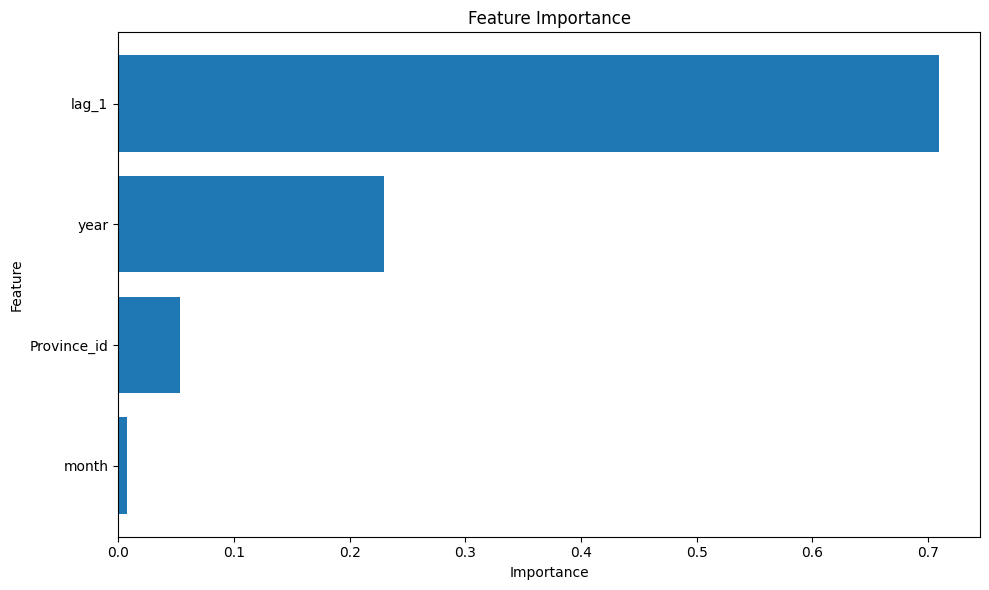

In [53]:
# Feature Importance
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    feature_importance_df = pd.DataFrame({'feature': FEATURE_COLS, 'importance': importances})
    feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

    print("\n=== Feature Importance ===")
    print(feature_importance_df)

    # Plot feature importance
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("Feature Importance")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Model has not been fitted yet. Please run the training cell first.")

# Knowledge Presentation



=== Random Forest Regression ===
Train Data : 80.0%
Train RMSE : 199.11
Train MAPE : 0.17%
Validation Data : 10.0%
Test Data  : 10.0%
Val RMSE   : 100.84
Val MAPE   : 0.41%
Test RMSE  : 124.48
Test MAPE  : 0.49%


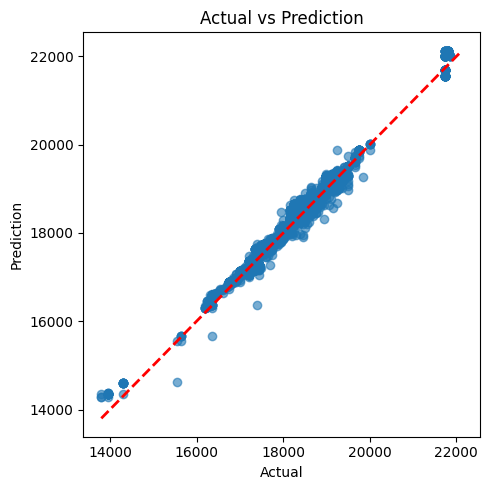

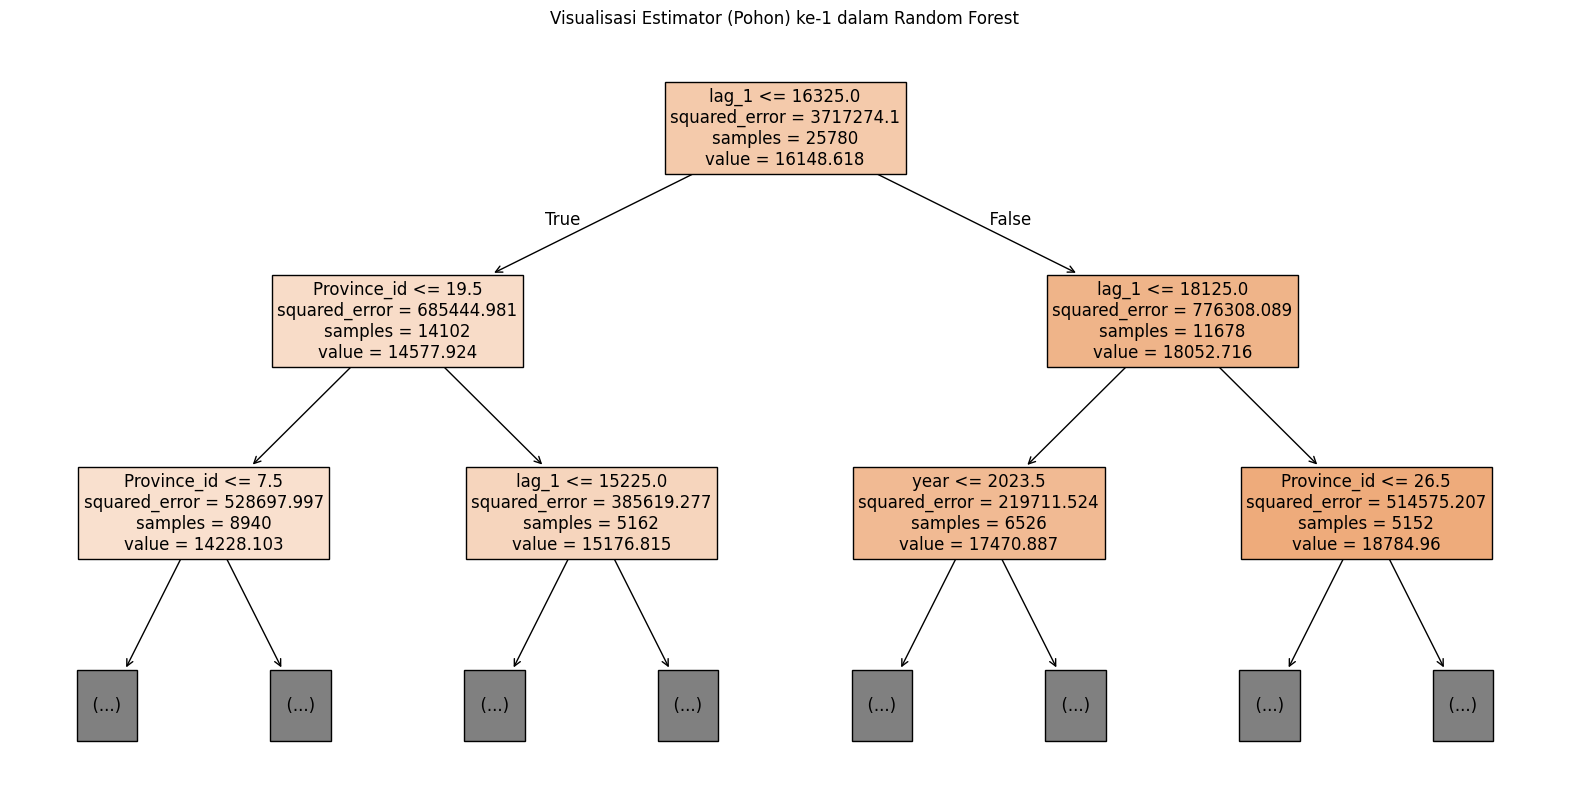

In [54]:
print("\n")
print("=== Random Forest Regression ===")
print(f"Train Data : {train_size*100:.1f}%")
print(f"Train RMSE : {overall_train_rmse:,.2f}")
print(f"Train MAPE : {overall_train_mape:.2f}%")
if use_validation:
    print(f"Validation Data : {validation_size*100:.1f}%")
    print(f"Test Data  : {(1 - train_size - validation_size)*100:.1f}%")
    print(f"Val RMSE   : {val_rmse:,.2f}")
    print(f"Val MAPE   : {val_mape:.2f}%")
else:
    print(f"Test Data  : {(1 - train_size)*100:.1f}%")
print(f"Test RMSE  : {rmse:,.2f}")
print(f"Test MAPE  : {mape:.2f}%")

# Determine test start index for saving prediction results
if use_validation:
    _test_start = int(len(df_mining) * train_size) + int(len(df_mining) * validation_size)
    _test_start = min(_test_start, len(df_mining))
else:
    _test_start = int(len(df_mining) * train_size)

# Save prediction results for analysis
mined_df = pd.DataFrame(
    {
        "Date": df_mining.iloc[_test_start:]["Date"].values,
        "Province": df_mining.iloc[_test_start:]["Province"].values,
        "Actual": y_test.values,
        "Prediction": y_pred,
    }
)

# Export dataframe
mined_df.to_excel(mined_dataset_path, index=False)

# Show scatter plot between actual data vs prediction
plt.figure(figsize=(5, 5))
plt.scatter(mined_df["Actual"], mined_df["Prediction"], alpha=0.6)
max_val = max(mined_df["Actual"].max(), mined_df["Prediction"].max())
min_val = min(mined_df["Actual"].min(), mined_df["Prediction"].min())
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)

plt.title("Actual vs Prediction")
plt.xlabel("Actual")
plt.ylabel("Prediction")
plt.tight_layout()
plt.show()

# Show tree visualization
n_trees_to_view = 1

for i in range(n_trees_to_view):
    plt.figure(figsize=(20, 10))
    tree.plot_tree(model.estimators_[i], 
                   feature_names=X.columns, 
                   filled=True, 
                   max_depth=2,
                   fontsize=12)
    plt.title(f"Visualisasi Estimator (Pohon) ke-{i+1} dalam Random Forest")
    plt.show()

## Deep Dive

In [55]:
print("="*60)
print("PROSES BOOTSTRAPPING PADA POHON PERTAMA")
print("="*60)

# Ambil pohon pertama (index 0) dari model yang sudah dilatih
pohon_pertama = model.estimators_[0]

# Dapatkan index baris data hasil bootstrapping
n_samples = X_train.shape[0]
bootstrap_indices = _generate_sample_indices(pohon_pertama.random_state, n_samples, n_samples)

print(f"Total data training asli : {n_samples} baris")
print(f"Total data di bootstrap  : {len(bootstrap_indices)} baris (ukuran sama, tapi ada duplikasi acak)\n")

print("="*60)
print("FITUR YANG DIPILIH OLEH POHON PERTAMA")
print("="*60)

# Atribut tree_.feature menyimpan index fitur yang digunakan untuk splitting
# Nilai -2 (atau kurang dari 0) menandakan node tersebut adalah "daun" (leaf/keputusan akhir), bukan fitur
fitur_terpakai_idx = set([f for f in pohon_pertama.tree_.feature if f >= 0])
fitur_terpakai_nama = [X_train.columns[i] for i in fitur_terpakai_idx]

print(f"Dari total {len(X_train.columns)} fitur yang tersedia, pohon pertama menggunakan fitur berikut:")
for fitur in fitur_terpakai_nama:
    print(f"- {fitur}")
print("\n")

print("="*60)
print("PENCARIAN DATA BOOTSTRAP YANG RELEVAN (UNTUK TABEL LAPORAN)")
print("="*60)

# Tentukan data evaluasi
X_eval = X_val if use_validation else X_test
y_eval = y_val if use_validation else y_test

# Ambil 1 baris data baru untuk diuji
sampel_uji = X_eval.iloc[[0]]
nilai_aktual = y_eval.iloc[0]

print(f"Nilai aktual yang diuji: Rp {nilai_aktual:,.0f}\n")

# Buat DataFrame sementara untuk data hasil bootstrap
df_bootstrap = X_train.iloc[bootstrap_indices].copy()
df_bootstrap['Harga_Actual_y'] = y_train.iloc[bootstrap_indices].values

# --- KUNCI VARIASI: Gunakan Rentang Margin ---
# Atur margin ± Rp 1.500 (Anda bisa mengubah angka ini jika ingin rentang lebih lebar/sempit)
margin = 1500
batas_bawah = nilai_aktual - margin
batas_atas = nilai_aktual + margin

print(f"Memfilter data dalam rentang: Rp {batas_bawah:,.0f} s.d Rp {batas_atas:,.0f}")

# Filter data agar hanya mengambil yang berada dalam rentang margin
df_range = df_bootstrap[(df_bootstrap['Harga_Actual_y'] >= batas_bawah) & 
                        (df_bootstrap['Harga_Actual_y'] <= batas_atas)]

# Hapus duplikasi agar tidak ada harga yang kembar
# LALU urutkan berdasarkan harga, BUKAN berdasarkan selisih.
df_variasi = df_range.drop_duplicates(subset=['Harga_Actual_y']).sort_values('Harga_Actual_y')

print(f"Ditemukan {len(df_variasi)} variasi harga yang unik dalam rentang tersebut.\n")

# --- GABUNGKAN 10 DATA MENJADI 1 TABEL UTUH ---
# Ambil 5 harga terendah dan 5 harga tertinggi, lalu gabungkan
df_manual = pd.concat([df_variasi.head(5), df_variasi.tail(5)]).drop_duplicates()

# Opsional: Acak sedikit urutannya agar terlihat seperti sampel natural (seperti di Tabel 18 PDF)
df_manual['Provinsi (Province Name)'] = df_mining.loc[df_manual.index, 'Province'].values
df_manual = df_manual.sample(frac=1, random_state=42).reset_index(drop=True)
# Jika ingin nomor indeks mulai dari 1 seperti di laporan:
df_manual.index = np.arange(1, len(df_manual) + 1)

print(f"Menampilkan 10 Data Sampel Acak (Salin tabel ini ke laporan Anda):")
df_manual = df_manual.rename(columns={'Harga_Actual_y': 'Harga (Price)'})
cols = ['Harga (Price)', 'Provinsi (Province Name)'] + [c for c in df_manual.columns if c not in ['Harga (Price)', 'Provinsi (Province Name)']]
df_manual = df_manual[cols]
display(df_manual)

PROSES BOOTSTRAPPING PADA POHON PERTAMA
Total data training asli : 40761 baris
Total data di bootstrap  : 40761 baris (ukuran sama, tapi ada duplikasi acak)

FITUR YANG DIPILIH OLEH POHON PERTAMA
Dari total 4 fitur yang tersedia, pohon pertama menggunakan fitur berikut:
- Province_id
- lag_1
- month
- year


PENCARIAN DATA BOOTSTRAP YANG RELEVAN (UNTUK TABEL LAPORAN)
Nilai aktual yang diuji: Rp 19,950

Memfilter data dalam rentang: Rp 18,450 s.d Rp 21,450
Ditemukan 34 variasi harga yang unik dalam rentang tersebut.

Menampilkan 10 Data Sampel Acak (Salin tabel ini ke laporan Anda):


,Harga (Price),Provinsi (Province Name),Province_id,lag_1,month,year
1,20150,Papua Barat,31,20150.0,4,2025
2,18500,Nusa Tenggara Timur,23,18500.0,1,2025
3,19950,Gorontalo,30,20000.0,5,2025
4,18450,Sumatera Barat,14,18700.0,2,2025
5,20100,Gorontalo,30,20100.0,5,2025
6,18550,Riau,13,18550.0,4,2025
7,20200,Gorontalo,30,20200.0,4,2025
8,18650,Maluku,29,18650.0,12,2024
9,18600,Gorontalo,30,18600.0,9,2024
10,20000,Gorontalo,30,20000.0,4,2025


In [56]:
print("\n" + "="*60)
print("PERHITUNGAN MANUAL TITIK SPLIT TERPILIH (ROOT NODE)")
print("="*60)

# 1. Ekstrak Aturan Root (Akar) dari Pohon Pertama
pohon_pertama = model.estimators_[0]
root_feature_idx = pohon_pertama.tree_.feature[0]
root_threshold = pohon_pertama.tree_.threshold[0]
root_feature_name = X_train.columns[root_feature_idx]

# 2. Siapkan SELURUH data latih dari hasil bootstrap
X_boot = X_train.iloc[bootstrap_indices].copy()
y_boot = y_train.iloc[bootstrap_indices].values

df_full = X_boot.copy()
df_full['Harga_Actual'] = y_boot
N_total = len(df_full)

fitur = root_feature_name
s = root_threshold

print(f"Menggunakan SELURUH data latih (bootstrap) sebanyak {N_total} baris.")
print(f"Fitur split terbaik yang dipilih program : '{fitur}'")

# 3. Urutkan data berdasarkan fitur
df_sorted = df_full.sort_values(fitur).reset_index(drop=True)

# Cari tahu asal-usul nilai s (rata-rata 2 nilai yang bersebelahan)
nilai_fitur_unik = np.unique(df_sorted[fitur].values)
idx_kiri = np.searchsorted(nilai_fitur_unik, s, side='right') - 1
idx_kanan = idx_kiri + 1

if idx_kiri >= 0 and idx_kanan < len(nilai_fitur_unik):
    val_kiri = nilai_fitur_unik[idx_kiri]
    val_kanan = nilai_fitur_unik[idx_kanan]
    print(f"Ambang batas (s) terpilih                : {s:.2f}")
    print(f"Asal-usul perhitungan nilai s            : ({val_kiri} + {val_kanan}) / 2 = {s:.2f}\n")
else:
    print(f"Ambang batas (s) terpilih                : {s:.2f}\n")

# --- FUNGSI FORMATTING "..." (DIPERBARUI) ---
def format_deret(arr, is_mse=False, mean_val=0):
    if len(arr) == 0:
        return "0"
        
    # KUNCI PERBAIKAN: Urutkan array berdasarkan nilai harga (kecil ke besar)
    # agar harga ekstrem (seperti 20.000) selalu terlihat di ekor deretan.
    arr_sorted = np.sort(arr)
    
    if len(arr_sorted) <= 5:
        if is_mse:
            return " + ".join([f"({x} - {mean_val:.2f})^2" for x in arr_sorted])
        else:
            return " + ".join([str(x) for x in arr_sorted])
    else:
        # Tampilkan 2 di awal (terendah) dan 2 di akhir (tertinggi), pisahkan dengan "..."
        if is_mse:
            return f"({arr_sorted[0]} - {mean_val:.2f})^2 + ({arr_sorted[1]} - {mean_val:.2f})^2 + ... + ({arr_sorted[-2]} - {mean_val:.2f})^2 + ({arr_sorted[-1]} - {mean_val:.2f})^2"
        else:
            return f"{arr_sorted[0]} + {arr_sorted[1]} + ... + {arr_sorted[-2]} + {arr_sorted[-1]}"

# 4. Eksekusi Perhitungan Manual HANYA untuk titik split terpilih
print(f"Uji Split Terpilih ({fitur} <= {s:.2f})")

# --- KELOMPOK KIRI ---
kiri = df_sorted[df_sorted[fitur] <= s]
n_L = len(kiri)
y_L = kiri['Harga_Actual'].values
mean_L = np.mean(y_L) if n_L > 0 else 0
mse_L = np.mean((y_L - mean_L)**2) if n_L > 0 else 0

str_y_L = format_deret(y_L)
str_mse_L = format_deret(y_L, is_mse=True, mean_val=mean_L)

# --- KELOMPOK KANAN ---
kanan = df_sorted[df_sorted[fitur] > s]
n_R = len(kanan)
y_R = kanan['Harga_Actual'].values
mean_R = np.mean(y_R) if n_R > 0 else 0
mse_R = np.mean((y_R - mean_R)**2) if n_R > 0 else 0

str_y_R = format_deret(y_R)
str_mse_R = format_deret(y_R, is_mse=True, mean_val=mean_R)

# --- MSE GABUNGAN ---
mse_split = (n_L / N_total) * mse_L + (n_R / N_total) * mse_R

# Format cetak mirip dengan laporan PDF
print(f"  a) Split kiri")
print(f"     n_L = {n_L}")
print(f"     y_L_bar = ({str_y_L}) / {n_L} = {mean_L:.2f}")
print(f"     MSE_L = 1/{n_L} * [{str_mse_L}] = {mse_L:.2f}")

print(f"  b) Split kanan")
print(f"     n_R = {n_R}")
print(f"     y_R_bar = ({str_y_R}) / {n_R} = {mean_R:.2f}")
print(f"     MSE_R = 1/{n_R} * [{str_mse_R}] = {mse_R:.2f}")

print(f"  c) Hitung nilai split gabungan")
print(f"     MSE_split = {n_L}/{N_total}({mse_L:.2f}) + {n_R}/{N_total}({mse_R:.2f}) = {mse_split:.2f}\n")

print("-" * 60)
print(f"Kesimpulan: Ini adalah evaluasi langsung untuk split terbaik yang membentuk Node Akar (Root Node) pada Pohon Pertama.")


PERHITUNGAN MANUAL TITIK SPLIT TERPILIH (ROOT NODE)
Menggunakan SELURUH data latih (bootstrap) sebanyak 40761 baris.
Fitur split terbaik yang dipilih program : 'lag_1'
Ambang batas (s) terpilih                : 16325.00
Asal-usul perhitungan nilai s            : (16300.0 + 16350.0) / 2 = 16325.00

Uji Split Terpilih (lag_1 <= 16325.00)
  a) Split kiri
     n_L = 22336
     y_L_bar = (11450 + 11450 + ... + 29450 + 36250) / 22336 = 14577.92
     MSE_L = 1/22336 * [(11450 - 14577.92)^2 + (11450 - 14577.92)^2 + ... + (29450 - 14577.92)^2 + (36250 - 14577.92)^2] = 685444.98
  b) Split kanan
     n_R = 18425
     y_R_bar = (13950 + 15950 + ... + 33250 + 33250) / 18425 = 18052.72
     MSE_R = 1/18425 * [(13950 - 18052.72)^2 + (15950 - 18052.72)^2 + ... + (33250 - 18052.72)^2 + (33250 - 18052.72)^2] = 776308.09
  c) Hitung nilai split gabungan
     MSE_split = 22336/40761(685444.98) + 18425/40761(776308.09) = 726517.40

------------------------------------------------------------
Kesimpulan: 

In [60]:
print("\n" + "="*60)
print("SIMULASI PREDIKSI DATA UJI PADA POHON PERTAMA")
print("="*60)

# 1. Ambil pohon pertama dan struktur internalnya
pohon_pertama = model.estimators_[0]
tree_ = pohon_pertama.tree_
fitur_names = X_train.columns
nomor_index_df = 40765

X_eval = X_val if use_validation else X_test
y_eval = y_val if use_validation else y_test

if nomor_index_df not in X_eval.index:
    print(f"Error: Nomor index {nomor_index_df} tidak ditemukan di set evaluasi. Pastikan nomornya benar.\n")
else:
    # 2. Ambil 1 baris data uji
    sampel_uji = X_eval.loc[[nomor_index_df]]
    nilai_aktual = y_eval.loc[nomor_index_df]

    print("Data Uji yang akan diprediksi:")
    display(sampel_uji)
    print(f"Harga Aktual (Target) : Rp {nilai_aktual:,.0f}\n")

    print("--- TRACING KEPUTUSAN POHON (DECISION PATH) ---")
    node_saat_ini = 0
    langkah = 1
    sejarah_langkah = [] # List untuk menyimpan riwayat perjalanan node

    # 3. Looping selama node saat ini BUKAN leaf node
    while tree_.children_left[node_saat_ini] != -1: 
        fitur_idx = tree_.feature[node_saat_ini]
        nama_fitur = fitur_names[fitur_idx]
        threshold = tree_.threshold[node_saat_ini]
        nilai_sampel = sampel_uji[nama_fitur].values[0]
        
        # Evaluasi kondisi
        if nilai_sampel <= threshold:
            keputusan = f"{nilai_sampel:.2f} <= {threshold:.2f} -> Jatuh ke cabang KIRI"
            next_node = tree_.children_left[node_saat_ini]
        else:
            keputusan = f"{nilai_sampel:.2f} > {threshold:.2f} -> Jatuh ke cabang KANAN"
            next_node = tree_.children_right[node_saat_ini]
            
        # Simpan data langkah ini ke dalam riwayat
        sejarah_langkah.append({
            'langkah': langkah,
            'node': node_saat_ini,
            'nama_fitur': nama_fitur,
            'threshold': threshold,
            'nilai_sampel': nilai_sampel,
            'keputusan': keputusan
        })
        
        node_saat_ini = next_node
        langkah += 1

    # --- MENAMPILKAN HASIL TRACING YANG DISIMPAN ---
    
    # Tampilkan Tahap Awal (Langkah 1)
    if len(sejarah_langkah) > 0:
        awal = sejarah_langkah[0]
        print(f"TAHAP AWAL (Langkah {awal['langkah']} | Node {awal['node']} - Root Node):")
        print(f"  - Aturan Split          : {awal['nama_fitur']} <= {awal['threshold']:.2f}")
        print(f"  - Input data uji        : {awal['nama_fitur']} = {awal['nilai_sampel']:.2f}")
        print(f"  - Keputusan             : {awal['keputusan']}\n")

    # Tampilkan pembatas jika ada lebih dari 2 langkah (ada node perantara yang disembunyikan)
    if len(sejarah_langkah) > 2:
        print("... [Proses pengecekan node perantara disembunyikan] ...\n")
        
    # Tampilkan Tahap Sebelum Akhir (Langkah N-1)
    # Berlaku jika pohon memiliki lebih dari 1 langkah (Root Node tidak langsung menunjuk ke Leaf Node)
    if len(sejarah_langkah) > 1:
        sebelum_akhir = sejarah_langkah[-1]
        print(f"TAHAP SEBELUM AKHIR (Langkah {sebelum_akhir['langkah']} | Node {sebelum_akhir['node']}):")
        print(f"  - Aturan Split          : {sebelum_akhir['nama_fitur']} <= {sebelum_akhir['threshold']:.2f}")
        print(f"  - Input data uji        : {sebelum_akhir['nama_fitur']} = {sebelum_akhir['nilai_sampel']:.2f}")
        print(f"  - Keputusan             : {sebelum_akhir['keputusan']}\n")

    # 4. Tahap Akhir: Mencapai Leaf Node
    nilai_prediksi = tree_.value[node_saat_ini][0][0]
    jumlah_sampel_daun = tree_.n_node_samples[node_saat_ini]

    print(f"TAHAP AKHIR (Langkah {langkah} | Node {node_saat_ini} - Leaf Node):")
    print(f"  - Status Node           : Simpul akhir (mencapai ujung cabang)")
    print(f"  - Jumlah Sampel Latih   : {jumlah_sampel_daun} sampel berada di daun ini")
    print(f"  - Dasar Prediksi        : Rata-rata harga dari {jumlah_sampel_daun} sampel tersebut")
    print(f"  - Keputusan (y_hat)     : Rp {nilai_prediksi:,.2f}\n")

    print("="*60)
    print(f"KESIMPULAN: Prediksi T1 = Rp {nilai_prediksi:,.2f} | Harga Aktual = Rp {nilai_aktual:,.0f}")
    print("="*60)


SIMULASI PREDIKSI DATA UJI PADA POHON PERTAMA
Data Uji yang akan diprediksi:


,Province_id,lag_1,month,year
40765,1,17150.0,5,2025


Harga Aktual (Target) : Rp 17,150

--- TRACING KEPUTUSAN POHON (DECISION PATH) ---
TAHAP AWAL (Langkah 1 | Node 0 - Root Node):
  - Aturan Split          : lag_1 <= 16325.00
  - Input data uji        : lag_1 = 17150.00
  - Keputusan             : 17150.00 > 16325.00 -> Jatuh ke cabang KANAN

... [Proses pengecekan node perantara disembunyikan] ...

TAHAP SEBELUM AKHIR (Langkah 10 | Node 876):
  - Aturan Split          : Province_id <= 1.50
  - Input data uji        : Province_id = 1.00
  - Keputusan             : 1.00 <= 1.50 -> Jatuh ke cabang KIRI

TAHAP AKHIR (Langkah 11 | Node 877 - Leaf Node):
  - Status Node           : Simpul akhir (mencapai ujung cabang)
  - Jumlah Sampel Latih   : 19 sampel berada di daun ini
  - Dasar Prediksi        : Rata-rata harga dari 19 sampel tersebut
  - Keputusan (y_hat)     : Rp 17,311.11

KESIMPULAN: Prediksi T1 = Rp 17,311.11 | Harga Aktual = Rp 17,150


In [61]:
# =====================================================================
# TAMBAHAN: MELIHAT DATA LATIH (SAMPEL) YANG BERADA DI DALAM LEAF NODE
# =====================================================================
print("\n" + "="*60)
print(f"MENGGALI ISI LEAF NODE {node_saat_ini}")
print("="*60)

# 1. Masukkan seluruh data latih ke dalam pohon ini untuk melihat mereka jatuh ke node mana
node_tujuan_semua_data_latih = pohon_pertama.apply(X_train)

# 2. Saring hanya data latih yang jatuh tepat di daun yang sama (node_saat_ini)
# Kita ambil X_train dan y_train yang sesuai
sampel_daun_X = X_train[node_tujuan_semua_data_latih == node_saat_ini]
sampel_daun_y = y_train[node_tujuan_semua_data_latih == node_saat_ini]

jumlah_asli = len(sampel_daun_X)
print(f"Ditemukan {jumlah_asli} baris data latih di dalam daun ini.")
print("Berikut adalah 5 data teratas dan terbawah yang membentuk nilai prediksi:\n")

# 3. Tampilkan 5 Data Teratas
print("--- 5 DATA TERATAS DI DALAM DAUN ---")
display(sampel_daun_X.head(5))
print("Target Aktual (y_train) 5 teratas:")
display(sampel_daun_y.head(5))

print("\n" + "-"*60 + "\n")

# 4. Tampilkan 5 Data Terbawah
print("--- 5 DATA TERBAWAH DI DALAM DAUN ---")
display(sampel_daun_X.tail(5))
print("Target Aktual (y_train) 5 terbawah:")
display(sampel_daun_y.tail(5))

# 5. Pembuktian Rata-rata
rata_rata_manual = sampel_daun_y.mean()
# Catatan: Jika nilai y_train adalah Series berdimensi 1, kita bisa langsung .mean()
# Jika outputnya DataFrame, pastikan mengambil kolom targetnya.
print("\n" + "="*60)
print(f"PEMBUKTIAN PREDIKSI:")
print(f"Rata-rata target (y_train) dari data di atas secara manual = Rp {rata_rata_manual:,.2f}")
print(f"Nilai prediksi asli dari Pohon (y_hat)                       = Rp {nilai_prediksi:,.2f}")
print("="*60)


MENGGALI ISI LEAF NODE 877
Ditemukan 35 baris data latih di dalam daun ini.
Berikut adalah 5 data teratas dan terbawah yang membentuk nilai prediksi:

--- 5 DATA TERATAS DI DALAM DAUN ---


/home/reyvn/Dev/Py/RFR-Sugar-Price/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


,Province_id,lag_1,month,year
36211,1,17050.0,1,2025
36244,1,17150.0,1,2025
36277,1,17100.0,1,2025
36310,1,17100.0,1,2025
36343,1,17100.0,1,2025


Target Aktual (y_train) 5 teratas:


36211    17150
36244    17100
36277    17100
36310    17100
36343    17150
Name: Price, dtype: int64


------------------------------------------------------------

--- 5 DATA TERBAWAH DI DALAM DAUN ---


,Province_id,lag_1,month,year
40600,1,17250.0,5,2025
40633,1,17200.0,5,2025
40666,1,17200.0,5,2025
40699,1,17200.0,5,2025
40732,1,17200.0,5,2025


Target Aktual (y_train) 5 terbawah:


40600    17200
40633    17200
40666    17200
40699    17200
40732    17150
Name: Price, dtype: int64


PEMBUKTIAN PREDIKSI:
Rata-rata target (y_train) dari data di atas secara manual = Rp 17,304.29
Nilai prediksi asli dari Pohon (y_hat)                       = Rp 17,311.11


In [62]:
import pandas as pd
import numpy as np

print("\n" + "="*60)
print("PREDIKSI INDIVIDUAL DARI MASING-MASING POHON")
print("="*60)

prediksi_individual = []
nama_pohon = []
total_pohon = len(model.estimators_)

# 1. Looping ke setiap pohon untuk mengumpulkan prediksi
for i, tree_estimator in enumerate(model.estimators_):
    # Menggunakan sampel_uji.values untuk menghindari warning nama fitur
    pred_tree = tree_estimator.predict(sampel_uji.values)[0]
    
    prediksi_individual.append(pred_tree)
    nama_pohon.append(f"Pohon ke-{i:02d}")

# 2. Buat Pandas DataFrame dari data yang terkumpul
df_prediksi = pd.DataFrame({
    'Pohon': nama_pohon,
    'Prediksi Harga (Asli)': prediksi_individual
})

# 3. Buat kolom baru khusus untuk tampilan dengan format Rupiah
df_prediksi['Prediksi Harga (Rp)'] = df_prediksi['Prediksi Harga (Asli)'].apply(lambda x: f"Rp {x:,.2f}")

# 4. Tampilkan tabel (Hanya menampilkan kolom Pohon dan Format Rupiah)
# Jika jumlah pohon sangat banyak (misal 100), Pandas akan otomatis 
# menyingkat tampilannya (menampilkan 5 teratas dan 5 terbawah)
display(df_prediksi[['Pohon', 'Prediksi Harga (Rp)']])


# 5. Bandingkan rata-rata dari seluruh pohon dengan prediksi akhir model
rata_rata_manual = np.mean(prediksi_individual)
prediksi_akhir_rf = model.predict(sampel_uji)[0]

print("\n" + "="*60)
print("KESIMPULAN PREDIKSI (Manual vs Program)")
print("="*60)
print(f"Rata-rata prediksi dari {total_pohon} pohon   : Rp {rata_rata_manual:,.2f}")
print(f"Prediksi akhir dari model (rf.predict) : Rp {prediksi_akhir_rf:,.2f}")
print("="*60)


PREDIKSI INDIVIDUAL DARI MASING-MASING POHON


,Pohon,Prediksi Harga (Rp)
0,Pohon ke-00,"Rp 17,311.11"
1,Pohon ke-01,"Rp 17,195.00"
2,Pohon ke-02,"Rp 17,200.00"
3,Pohon ke-03,"Rp 17,189.29"
4,Pohon ke-04,"Rp 17,148.97"
...,...,...
70,Pohon ke-70,"Rp 17,286.84"
71,Pohon ke-71,"Rp 17,397.50"
72,Pohon ke-72,"Rp 17,185.71"
73,Pohon ke-73,"Rp 17,296.15"



KESIMPULAN PREDIKSI (Manual vs Program)
Rata-rata prediksi dari 75 pohon   : Rp 17,207.12
Prediksi akhir dari model (rf.predict) : Rp 17,207.12


# Optional

## Generate Sugar Price History Plot

In [ ]:
if generate_history_plot :
    df = df_merged.copy()

    # Specify where output will be stored
    combined_path = Path(f"../output/{sugar_type}/plots/sugar_price_history.png")
    province_dir = Path(f"../output/{sugar_type}/plots/province_price_history/")
    combined_path.parent.mkdir(parents=True, exist_ok=True)
    province_dir.mkdir(parents=True, exist_ok=True)

    # All provinces combined plot
    plt.figure(figsize=(12, 6))

    for prov, g in df.groupby("Province"):
        plt.plot(g["Date"], g["Price"], label=prov, linewidth=0.8, alpha=0.7)

    plt.title("Riwayat Harga Gula per Provinsi")
    plt.xlabel("Tanggal")
    plt.ylabel("Harga (Rp)")
    plt.legend(
        title="Provinsi", fontsize=6, ncol=2, bbox_to_anchor=(1.05, 1), loc="upper left"
    )
    plt.tight_layout()
    plt.savefig(combined_path)
    plt.close()

    # Each individual province plot
    for prov, g in df.groupby("Province"):
        plt.figure(figsize=(10, 5))
        plt.plot(g["Date"], g["Price"], linewidth=1.5)

        plt.title(f"Riwayat Harga Gula - {prov}")
        plt.xlabel("Tanggal")
        plt.ylabel("Harga (Rp)")
        plt.tight_layout()

        file_name = prov.replace(" ", "_").replace("/", "_") + ".png"
        plt.savefig(province_dir / file_name)
        plt.close()
else :
    print("Skip Generating Sugar Price History Plot")

## Generate PACF Plot

In [ ]:
if generate_pacf_plot :    
    df = df_transform.copy()
    y_full = df['Price'].astype(float)
    max_lag = 31

    # Plot PACF
    fig, ax = plt.subplots(figsize=(10, 4))
    plot_pacf(y_full, ax=ax, lags=max_lag, method="ywm")    # Method Yule-Walker Modified
    ax.set_title(f"PACF Harga Gula Pasir ({sugar_type})")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Partial Autocorrelation")
    plt.tight_layout()
    plt.show()

    # Create PACF value as numeric + confidence interval
    pacf_vals, confint = pacf(
        y_full,
        nlags=max_lag,
        alpha=0.05, # 95% confidence interval
        method="ywm"
    )

    # Find significant lags
    significant_lags = [
        lag for lag in range(1, len(pacf_vals))
        if (confint[lag, 0] > 0) or (confint[lag, 1] < 0)
    ]

    print("Lag yang signifikan menurut PACF:", significant_lags)
else :
    print("Skip Generating PACF Plot")

## Compare Between Actual and Prediction Data

In [ ]:
if compare_prediction :
    # Specify where outputs will be stored
    output_dir = Path(f"../output/{sugar_type}/xlsx")
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"rfr_comparison.xlsx"
    compare_plot_dir = Path(f"../output/{sugar_type}/plots/compare")
    compare_plot_dir.mkdir(parents=True, exist_ok=True)

    # Use the model and split from the Data Mining section — no retraining.
    # Recover the Date and Province columns for the test-set rows from df_mining.
    split_idx = int(len(df_mining) * train_size)
    if use_validation:
        val_end_idx = min(split_idx + int(len(df_mining) * validation_size), len(df_mining))
        df_test_meta = df_mining.iloc[val_end_idx:].reset_index(drop=True)
    else:
        df_test_meta = df_mining.iloc[split_idx:].reset_index(drop=True)

    # Predict using the already-trained model (from Data Mining)
    y_pred_compare = model.predict(X_test)

    # Build result dataframe with Date and Province
    result_df = pd.DataFrame({
        "Date": df_test_meta["Date"].values,
        "Province": df_test_meta["Province"].values,
        "Actual": y_test.values,
        "Prediction": y_pred_compare,
    })

    # Evaluate model on the test set
    rmse_compare = root_mean_squared_error(result_df["Actual"], result_df["Prediction"])
    mape_compare = mean_absolute_percentage_error(result_df["Actual"], result_df["Prediction"]) * 100
    print(f"Test RMSE : {rmse_compare:.2f}")
    print(f"Test MAPE : {mape_compare:.4f}%")

    result_df.to_excel(output_path, index=False)

    # --- Plot per province ---
    for prov in sorted(result_df["Province"].unique()):
        sub = result_df[result_df["Province"] == prov].sort_values("Date")

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(sub["Date"], sub["Actual"], label="Actual", linewidth=1.2)
        ax.plot(sub["Date"], sub["Prediction"], label="Prediction", linewidth=1.2, linestyle="--")
        ax.set_title(f"Actual vs Predicted Price - {prov} ({sugar_type})")
        ax.set_xlabel("Date")
        ax.set_ylabel("Price (Rp)")
        ax.legend()
        fig.tight_layout()
        safe_filename = prov.replace("/", "_").replace(" ", "_")
        fig.savefig(compare_plot_dir / f"{safe_filename}.png")
        plt.close(fig)

    # --- Plot mean province (average across all provinces per date) ---
    df_mean = (
        result_df.groupby("Date")[["Actual", "Prediction"]]
        .mean()
        .reset_index()
        .sort_values("Date")
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df_mean["Date"], df_mean["Actual"], label="Mean Actual", linewidth=1.5, color="steelblue")
    ax.plot(df_mean["Date"], df_mean["Prediction"], label="Mean Prediction", linewidth=1.5, linestyle="--", color="tomato")
    ax.set_title(f"Mean Province - Actual vs Predicted Price ({sugar_type})")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (Rp)")
    ax.legend()
    fig.tight_layout()
    fig.savefig(compare_plot_dir / "mean_province.png")
    plt.show()
    plt.close(fig)
else :
    print("Skip Comparing Actual and Prediction Data")

## Forecast Future Data

In [ ]:
if forecast_price :
    df = df_transform.copy()

    X_full = df[FEATURE_COLS]
    y_full = df[TARGET_COL]

    # Create Random Forest Regression Model
    model = RandomForestRegressor(**RFR_PARAMS)
    model.fit(X_full, y_full)

    # Specify how much data should be predicted
    horizon = 180

    forecast_results = []
    provinces = df["Province"].unique()

    # Specify where forecast output will be stored
    forecast_plot_dir = Path(f"../output/{sugar_type}/plots/forecast/")
    forecast_plot_dir.mkdir(parents=True, exist_ok=True)
    forecast_output_path = Path(f"../output/{sugar_type}/xlsx/rfr_forecast_future_data.xlsx")
    forecast_output_path.parent.mkdir(parents=True, exist_ok=True)

    # Forecast loop each province
    for prov in provinces:
        g = df[df["Province"] == prov].copy()
        g = g.sort_values("Date").reset_index(drop=True)

        last_date = g["Date"].max()
        last_rows = g.tail(30).copy()

        future_rows = []

        prov_id = g.iloc[-1]["Province_id"]

        # Forecast loop until specified horizon
        for i in range(1, horizon + 1):
            next_date = last_date + pd.Timedelta(days=i)
            
            # Time Based Features
            month = next_date.month
            year  = next_date.year

            # Lag Features
            lag_1  = last_rows.iloc[-1]["Price"]

            # Arrange future data features
            X_future = pd.DataFrame({
                "Province_id": [prov_id],
                "lag_1": [lag_1],
                "month": [month],
                "year": [year]
            })

            predicted_price = model.predict(X_future)[0]

            forecast_results.append({
                "Date": next_date,
                "Province": prov,
                "Prediction": round(predicted_price),
            })

            future_rows.append({
                "Date": next_date,
                "Price": predicted_price
            })

            # Update series
            last_rows = pd.concat([
                last_rows,
                pd.DataFrame([{
                    "Date": next_date,
                    "Price": predicted_price,
                    "Province": prov,
                    "Province_id": prov_id,
                }])
            ], ignore_index=True)

        # Plot
        history_cutoff = last_date - pd.DateOffset(months=6)
        g_recent = g[g["Date"] >= history_cutoff]

        future_df = pd.DataFrame(future_rows)

        plt.figure(figsize=(12, 5))
        plt.plot(g_recent["Date"], g_recent["Price"], label="Historical", linewidth=1.5)
        plt.plot(future_df["Date"], future_df["Price"], label=f"Forecast ({horizon} days)", linewidth=1.5)

        plt.title(f"Forecast Harga Gula - {prov}")
        plt.xlabel("Tanggal")
        plt.ylabel("Harga (Rp)")
        plt.legend()
        plt.tight_layout()

        file_name = prov.replace(" ", "_").replace("/", "_") + "_forecast.png"
        plt.savefig(forecast_plot_dir / file_name, dpi=150, bbox_inches="tight")
        plt.close()

    # Export Forecast Dataframe
    df_forecast = pd.DataFrame(forecast_results)
    df_forecast = df_forecast.sort_values(["Province", "Date"]).reset_index(drop=True)
    df_forecast.to_excel(forecast_output_path, index=False)
else :
    print("Skip Forecasting Sugar Prices")